<a href="https://colab.research.google.com/github/Adi212004/Customer-Segmentation-using-ML/blob/main/Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("Customer_Trans_RFM_Analysis.csv")

# Select relevant features
rfm = df[['recency', 'frequency', 'monetary']]
print(rfm.head())

   recency  frequency  monetary
0       75          3    645.99
1       20          7   4179.11
2       56          6   4965.43
3      121          7   3983.97
4       75         10   6646.00


## **Data Preprocessing**
Hierarchical clustering uses distance, so scaling is required.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# **Build Dendrogram (Core of Hierarchical Clustering)**
This helps decide the number of clusters.

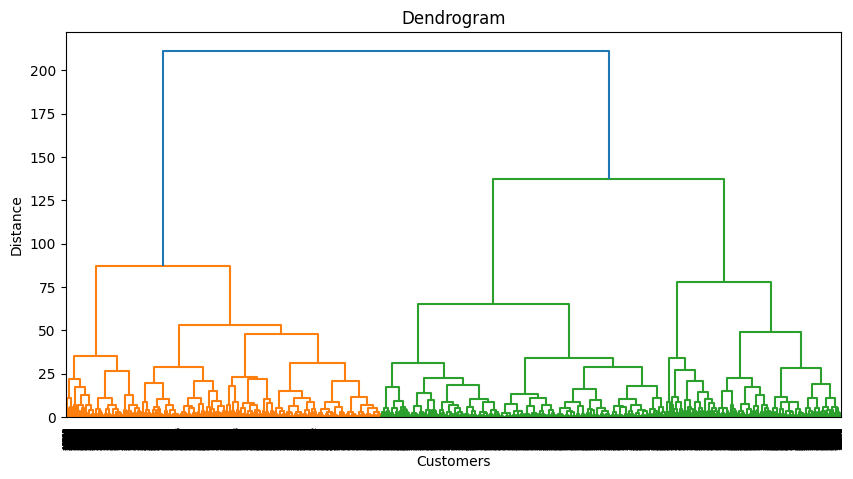

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(rfm_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# **Agglomerative Clustering**

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = hc.fit_predict(rfm_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters

# **Analyze Clusters**

In [ ]:
cluster_summary = df.groupby('Cluster')[['recency','frequency','monetary']].mean()
print(cluster_summary)

            recency  frequency     monetary
Cluster                                    
0        123.513650   4.926589  2640.245809
1         36.902680   8.049246  4708.675958
2         31.131627   5.420757  2447.989499
3         19.774817  10.352142  6975.532628


# **Visualize Clusters**

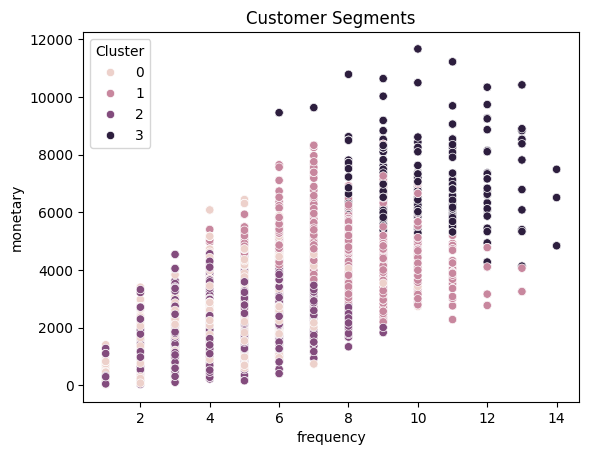

In [ ]:
import seaborn as sns

sns.scatterplot(x=df['frequency'], y=df['monetary'], hue=df['Cluster'])
plt.title("Customer Segments")
plt.show()